<a href="https://colab.research.google.com/github/Skye-Zhangg/Homework/blob/main/hw4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Task 2 (50 points): In this task, you will pick a dataset (time-series or any other form of
sequential data) and an associated problem that can be solved via sequence models. You must
describe why you need sequence models to solve this problem. Include a link to the dataset
source. Next, you should pick an RNN framework that you would use to solve this problem (This
framework can be in TensorFlow, PyTorch or any other Python Package).

Part 1 (10 points): Implement your RNN either using an existing framework OR you can
implement your own RNN cell structure. In either case, describe the structure of your
RNN and the activation functions you are using for each time step and in the output
layer. Define a metric you will use to measure the performance of your model (NOTE:
Performance should be measured both for the validation set and the test set).

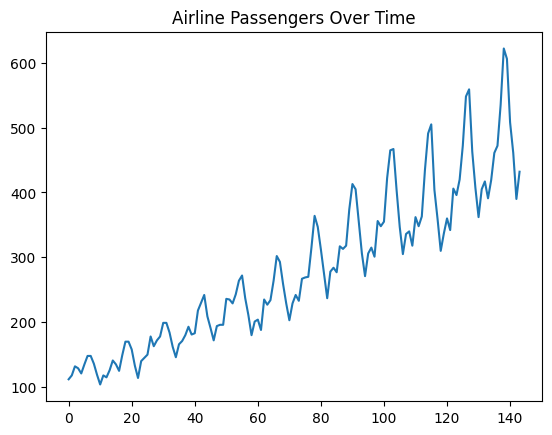

In [6]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#Load Dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"

data = pd.read_csv(url)

values = data["Passengers"].values.astype(float)

plt.plot(values)
plt.title("Airline Passengers Over Time")
plt.show()

In [7]:
from sklearn.preprocessing import MinMaxScaler
#Normalize
scaler = MinMaxScaler()

values = scaler.fit_transform(values.reshape(-1,1))

In [8]:

#Build sequences
seq_len = 12

X = []
y = []

for i in range(len(values)-seq_len):
    X.append(values[i:i+seq_len])
    y.append(values[i+seq_len])

X = np.array(X)
y = np.array(y)

print(X.shape)

(132, 12, 1)


In [9]:
#Train / Val / Test split
train_size = int(len(X)*0.7)
val_size = int(len(X)*0.15)

X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:train_size+val_size]
y_val = y[train_size:train_size+val_size]

X_test = X[train_size+val_size:]
y_test = y[train_size+val_size:]

In [10]:
#Convert to Torch
X_train = torch.tensor(X_train,dtype=torch.float32)
y_train = torch.tensor(y_train,dtype=torch.float32)

X_val = torch.tensor(X_val,dtype=torch.float32)
y_val = torch.tensor(y_val,dtype=torch.float32)

X_test = torch.tensor(X_test,dtype=torch.float32)
y_test = torch.tensor(y_test,dtype=torch.float32)

In [11]:
#LSTM Model
class LSTMModel(nn.Module):

    def __init__(self):

        super().__init__()

        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=64,
            num_layers=1,
            batch_first=True
        )

        self.fc = nn.Linear(64,1)

    def forward(self,x):

        out,_ = self.lstm(x)

        out = out[:,-1,:]

        return self.fc(out)

In [29]:
#train
model = LSTMModel()

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(model.parameters(),lr=0.01)

train_losses=[]
val_losses=[]
for epoch in range(200):

    model.train()

    output = model(X_train)

    loss = criterion(output,y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model.eval()

    val_output = model(X_val)

    val_loss = criterion(val_output,y_val)

    train_losses.append(loss.item())
    val_losses.append(val_loss.item())

model.eval()

with torch.no_grad():
    pred = model(X_test)

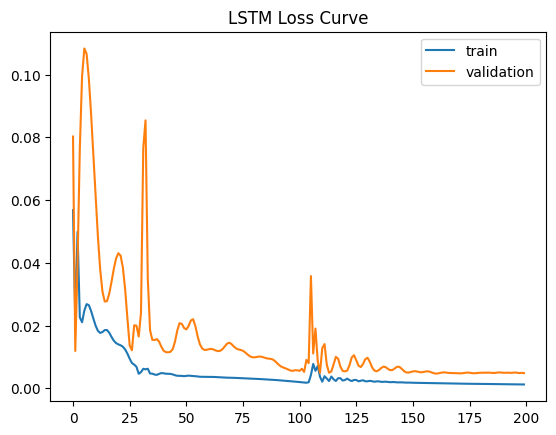

In [30]:
#Plot Loss
plt.plot(train_losses,label="train")
plt.plot(val_losses,label="validation")

plt.legend()
plt.title("LSTM Loss Curve")
plt.show()

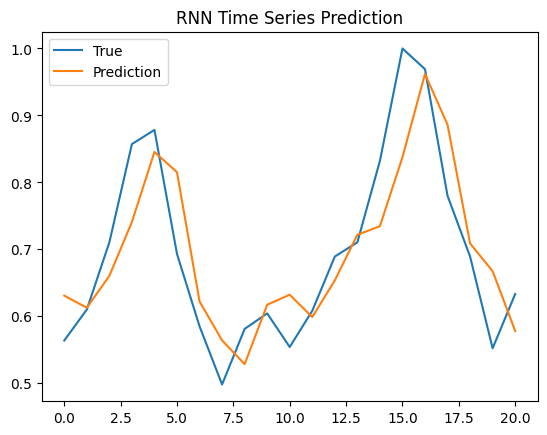

In [31]:
plt.plot(y_test,label="True")
plt.plot(pred.detach().numpy(),label="Prediction")

plt.legend()
plt.title("RNN Time Series Prediction")

plt.show()

In [32]:
import torch
import torch.nn as nn
import torch.nn.functional as F
mse = F.mse_loss(pred,y_test)
rmse = torch.sqrt(mse)
mae = F.l1_loss(pred,y_test)

print("MSE:",mse.item())
print("RMSE:",rmse.item())
print("MAE:",mae.item())

MSE: 0.005558000411838293
RMSE: 0.07455199956893921
MAE: 0.05987140163779259


**Dataset** We use the Airline Passengers dataset, which records the total number of airline passengers per month from 1949 to 1960. The dataset contains sequential time-series observations and is commonly used for evaluating forecasting models. Each observation represents the passenger count for a specific month.

**Why Sequence Models**
A sequence model is required because airline passenger counts exhibit temporal dependencies and seasonal patterns. The number of passengers in a given month is strongly influenced by previous months due to long-term trends and recurring seasonal fluctuations. Traditional models that treat observations independently cannot capture these sequential relationships. Recurrent neural networks process inputs sequentially and maintain hidden states that summarize previous observations, allowing them to model temporal dependencies effectively.

**Activation Functions** Inside the LSTM cell, the sigmoid activation function is used for the input, forget, and output gates, while the tanh activation function is used to update the cell state. The final output layer uses a linear activation because the problem is a regression task where the goal is to predict a continuous value.

**Evaluation Metric** We evaluate model performance using MSE, MAE and RMSE. The low values of MSE, RMSE, and MAE indicate that the LSTM model predicts passenger numbers with relatively small errors. The model successfully captures the temporal patterns in the airline passenger time series.

Part 2 (30 points): Update your network from part 1 with first an LSTM and then a GRU
based cell structure (You can treat both as 2 separate implementations). Re-do the
training and performance evaluation. What are the major differences you notice? Why
do you think those differences exist between the 3 implementations (basic RNN, LSTM
and GRU)?

In [15]:
import torch
import torch.nn as nn

class SequenceModel(nn.Module):

    def __init__(self, model_type="RNN"):
        super().__init__()

        hidden_size = 64

        if model_type == "RNN":
            self.rnn = nn.RNN(1, hidden_size, batch_first=True)

        elif model_type == "LSTM":
            self.rnn = nn.LSTM(1, hidden_size, batch_first=True)

        elif model_type == "GRU":
            self.rnn = nn.GRU(1, hidden_size, batch_first=True)

        self.fc = nn.Linear(hidden_size,1)

    def forward(self,x):

        out,_ = self.rnn(x)

        out = out[:,-1,:]

        return self.fc(out)

In [16]:
def train_model(model, X_train, y_train, X_val, y_val, epochs=200):

    criterion = nn.MSELoss()

    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

    train_losses=[]
    val_losses=[]

    for epoch in range(epochs):

        model.train()

        output = model(X_train)

        loss = criterion(output, y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        model.eval()

        val_output = model(X_val)

        val_loss = criterion(val_output, y_val)

        train_losses.append(loss.item())
        val_losses.append(val_loss.item())

    return train_losses, val_losses

In [34]:
def evaluate(model, X_test, y_test):

    model.eval()

    criterion = nn.MSELoss()

    with torch.no_grad():

        pred = model(X_test)

        test_loss = criterion(pred, y_test)

    return test_loss.item(), pred

In [37]:


def compute_metrics(pred, y):

    mse = F.mse_loss(pred, y)

    rmse = torch.sqrt(mse)

    mae = F.l1_loss(pred, y)

    return mse.item(), rmse.item(), mae.item()

In [47]:
# basic rnn
rnn_model = SequenceModel("RNN")

rnn_train, rnn_val = train_model(rnn_model, X_train, y_train, X_val, y_val)

rnn_test, rnn_pred = evaluate(rnn_model, X_test, y_test)



In [48]:
#lstm
lstm_model = SequenceModel("LSTM")

lstm_train, lstm_val = train_model(lstm_model, X_train, y_train, X_val, y_val)

lstm_test, lstm_pred  = evaluate(lstm_model, X_test, y_test)



In [49]:
#gru
gru_model = SequenceModel("GRU")

gru_train, gru_val = train_model(gru_model, X_train, y_train, X_val, y_val)

gru_test, gru_pred = evaluate(gru_model, X_test, y_test)


In [50]:
rnn_mse, rnn_rmse, rnn_mae = compute_metrics(rnn_pred, y_test)

lstm_mse, lstm_rmse, lstm_mae = compute_metrics(lstm_pred, y_test)

gru_mse, gru_rmse, gru_mae = compute_metrics(gru_pred, y_test)

In [51]:
import pandas as pd

df = pd.DataFrame({

    "Model":["RNN","LSTM","GRU"],

    "MSE":[rnn_mse,lstm_mse,gru_mse],

    "RMSE":[rnn_rmse,lstm_rmse,gru_rmse],

    "MAE":[rnn_mae,lstm_mae,gru_mae]

})

print(df)

  Model       MSE      RMSE       MAE
0   RNN  0.004460  0.066785  0.054193
1  LSTM  0.004682  0.068429  0.056639
2   GRU  0.011054  0.105140  0.079743


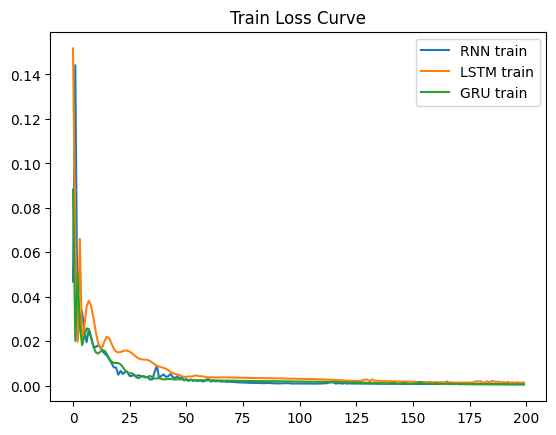

In [52]:
import matplotlib.pyplot as plt

plt.plot(rnn_train,label="RNN train")
plt.plot(lstm_train,label="LSTM train")
plt.plot(gru_train,label="GRU train")


plt.legend()
plt.title("Train Loss Curve")
plt.show()

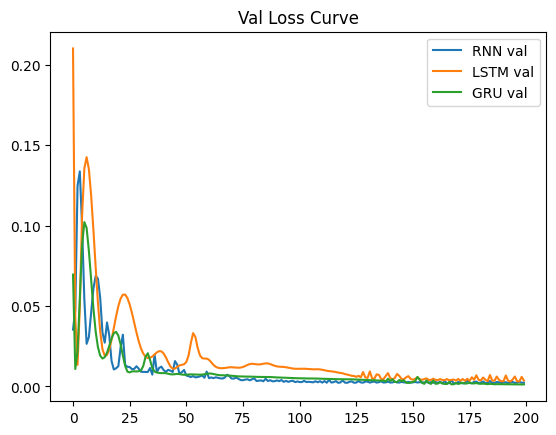

In [53]:
plt.plot(rnn_val,label="RNN val")
plt.plot(lstm_val,label="LSTM val")
plt.plot(gru_val,label="GRU val")
plt.legend()
plt.title("Val Loss Curve")
plt.show()


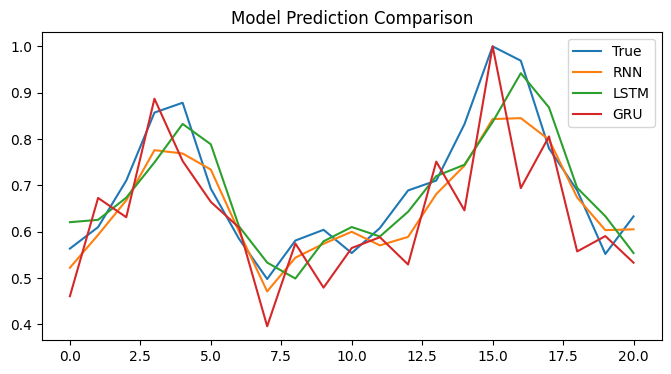

In [54]:
plt.figure(figsize=(8,4))

plt.plot(y_test.numpy(), label="True")

plt.plot(rnn_pred.detach().numpy(), label="RNN")
plt.plot(lstm_pred.detach().numpy(), label="LSTM")
plt.plot(gru_pred.detach().numpy(), label="GRU")

plt.legend()

plt.title("Model Prediction Comparison")

plt.show()

The experimental results show clear differences among the three sequence models. Based on the evaluation metrics (MSE, RMSE, and MAE), the basic RNN achieves the lowest prediction error, while LSTM performs very similarly but slightly worse, and GRU shows the highest error. The training and validation loss curves indicate that all three models converge quickly and learn the temporal patterns in the data, but the GRU model exhibits slightly higher instability and larger validation errors. From the prediction comparison plot, both RNN and LSTM follow the overall trend of the true time-series values more closely, while GRU deviates more at peaks and valleys. These differences likely arise from the architectural complexity of the models. The airline passenger dataset is relatively small and contains short-term temporal dependencies, so a simple RNN is already sufficient to capture the sequential patterns. While LSTM and GRU are designed with gating mechanisms to handle long-term dependencies and mitigate vanishing gradient problems, their advantages are not fully utilized in this task, which explains why the simpler RNN performs competitively and even slightly better.

Part 3 (10 points): Can you use the traditional feed-forward network to solve the same
problem. Why or why not? (Hint: Can time series data be converted to usual features
that can be used as input to a feed-forward network?)

A traditional feed-forward neural network could be applied to this problem by converting the time series into fixed-length feature vectors. For example, the passenger counts from the previous 12 months can be used as input features to predict the passenger count of the next month.

However, feed-forward networks do not explicitly model temporal dependencies because they process all inputs simultaneously rather than sequentially. In contrast, recurrent neural networks process data in time order and maintain hidden states that summarize historical information.

As a result, sequence models such as RNNs, LSTMs, and GRUs are generally more suitable for time-series forecasting tasks because they can better capture temporal patterns and long-term dependencies in sequential data.


Task 3 (50 points):
Part 1: Implementing Word Embeddings (10 points)
• Use a pre-trained word embedding model (Word2Vec, GloVe, FastText, or BERT
embeddings).

• Provide a comparative discussion on why you chose this embedding over others.

• Load embeddings efficiently (either from pre-trained vectors or using an NLP library like
Gensim, SpaCy, or Hugging Face).

• Allow dynamic user input of two words and output their respective embeddings.

• Handle cases where a word is out of vocabulary (OOV) and suggest ways to approximate
its embedding.

In [55]:
!pip install gensim
!pip install gensim-downloader

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 52.5 MB/s eta 0:00:00
ERROR: Could not find a version that satisfies the requirement gensim-downloader (from versions: none)
ERROR: No matching distribution found for gensim-downloader


In [56]:
import gensim.downloader as api
#Use a pre-trained embedding model
print("Loading Word2Vec model...")

model = api.load("word2vec-google-news-300")

print("Model loaded")
print(model.vector_size)

Loading Word2Vec model...
[==================================================] 100.0% 1662.8/1662.8MB downloaded
Model loaded
300


In [57]:
#dynamic user input of two words
word1 = input("Enter first word: ")
word2 = input("Enter second word: ")

Enter first word: hi
Enter second word: night


In [58]:
def get_embedding(word):

    if word in model:
        return model[word]

    else:
        print(f"{word} not in vocabulary")

        return None

In [59]:
vec1 = get_embedding(word1)
vec2 = get_embedding(word2)

In [60]:
if vec1 is not None:
    print(f"\nEmbedding for {word1}:")
    print(vec1[:10])  # show first 10 values

if vec2 is not None:
    print(f"\nEmbedding for {word2}:")
    print(vec2[:10])


Embedding for hi:
[-0.16503906  0.20410156  0.13085938  0.28710938 -0.16894531 -0.00366211
  0.17285156 -0.27539062 -0.03613281  0.03198242]

Embedding for night:
[ 0.01574707  0.07666016 -0.03222656  0.0201416   0.01525879 -0.05297852
 -0.01446533 -0.1953125   0.05883789  0.125     ]


In [61]:
def handle_oov(word):

    if word in model:
        return model[word]

    lower = word.lower()

    if lower in model:
        print("Using lowercase version")
        return model[lower]

    print("Word not found in vocabulary")

    return None

In this project we use pre-trained Word2Vec embeddings trained on the Google News dataset. Word2Vec represents words as dense continuous vectors that capture semantic relationships between words. Words with similar meanings tend to have similar vector representations in the embedding space.

We chose Word2Vec because it is widely used and easy to integrate using the Gensim library. Compared to more complex models such as BERT, Word2Vec requires significantly fewer computational resources while still providing meaningful semantic representations. For tasks that require simple word embeddings, Word2Vec provides a good balance between efficiency and performance.

Out-of-vocabulary (OOV) words occur when a word does not appear in the vocabulary of the pre-trained embedding model. This may happen for rare words, misspellings, or newly created terms. In our implementation, if a word is not found in the vocabulary, the system reports that the word is not available.

Several strategies can be used to approximate embeddings for OOV words. One approach is to normalize the word by converting it to lowercase or removing punctuation. Another approach is to use models such as FastText, which represent words using character-level n-grams. FastText can generate embeddings for unseen words by combining subword representations.



Part 2: Cosine Similarity Computation (20 points)

• Implement a function that computes the cosine similarity between two-word
embeddings.

• Explain why cosine similarity is useful in word embedding space.

• Allow batch processing, where users can input multiple word pairs for simultaneous
similarity computation.

• Visualization Requirement: Create a 2D or 3D scatter plot (e.g., using PCA or t-SNE) to
visually show how similar and dissimilar words cluster together in the embedding space.

In [ ]:
import numpy as np

def cosine_similarity(vec1, vec2):

    return np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2))

In [ ]:
if vec1 is not None and vec2 is not None:

    sim = cosine_similarity(vec1, vec2)

    print(f"Cosine similarity between {word1} and {word2}: {sim}")

Cosine similarity between morning and night: 0.6452910304069519


In [ ]:
#multiple word pairs
pairs = [
    ("man","woman"),
    ("train","apple"),
    ("girl","boy"),
    ("hello","food")
]

for w1, w2 in pairs:

    v1 = get_embedding(w1)
    v2 = get_embedding(w2)

    if v1 is not None and v2 is not None:

        sim = cosine_similarity(v1, v2)

        print(f"{w1} - {w2} similarity: {sim}")

man - woman similarity: 0.7664011716842651
train - apple similarity: 0.047209739685058594
girl - boy similarity: 0.8543272614479065
hello - food similarity: 0.05359866842627525


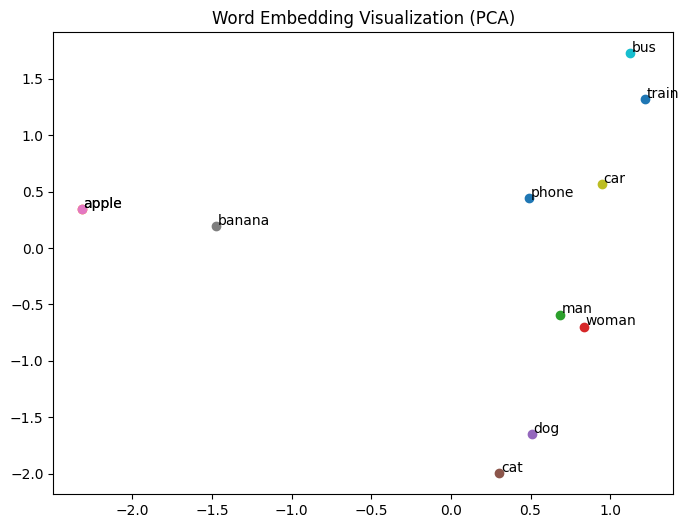

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
#choose words
words = [
    "train","apple","man","woman",
    "dog","cat","apple","banana",
    "car","bus","phone"
]

vectors = []

valid_words = []

for w in words:

    if w in model:
        vectors.append(model[w])
        valid_words.append(w)

vectors = np.array(vectors)
#pca
pca = PCA(n_components=2)
result = pca.fit_transform(vectors)
#plot
plt.figure(figsize=(8,6))

for i, word in enumerate(valid_words):

    x = result[i,0]
    y = result[i,1]

    plt.scatter(x,y)
    plt.text(x+0.01,y+0.01,word)

plt.title("Word Embedding Visualization (PCA)")
plt.show()

Cosine similarity is commonly used to measure the similarity between word embeddings. Word embeddings represent words as high-dimensional vectors where semantic relationships are encoded in the vector directions. Cosine similarity measures the angle between two vectors, which indicates how similar their semantic meanings are. Words with similar meanings tend to have vectors that point in similar directions, resulting in a cosine similarity value close to 1. Words that are unrelated have values close to 0.

Batch similarity computation allows multiple word pairs to be evaluated simultaneously. This helps compare semantic relationships across several word pairs efficiently. In our experiments, semantically related words such as “man–woman” and “girl–boy” show high similarity values, while unrelated pairs such as “train–apple” show very low similarity.

To visualize the embedding space, we applied Principal Component Analysis (PCA) to reduce the high-dimensional embeddings into two dimensions. The resulting scatter plot shows that semantically related words cluster together in the embedding space. For example, transportation-related words such as “car,” “bus,” and “train” appear close to each other, while animals such as “dog” and “cat” also form a cluster. This visualization demonstrates that word embeddings capture meaningful semantic relationships.


Part 3: Designing a Novel Dissimilarity Metric (20 points)
• Define a custom dissimilarity score that goes beyond cosine similarity. Possible
approaches include:

  o Euclidean distance (How far apart words are in vector space).
  o Word entropy-based dissimilarity (How uncommon two words are relative to each other in corpora).

  o Semantic contrast measure (Using external knowledge bases like WordNet).

• Either design your own metric or cite an existing one from literature (provide a proper
reference). Explain why your metric captures novelty/diversity better than cosine
similarity alone.

• Allow users to toggle between different similarity/dissimilarity measures via function
parameters.

• Visualization Requirement:

o Plot the ranking of words based on their similarity/dissimilarity to a given word
(e.g., how words like "cat" rank against "dog," "lion," and "table" using different
metrics).

o Use a heatmap to demonstrate and compare similarity and dissimilarity across
multiple (any number of your choice) word pairs.

In [ ]:
import numpy as np
#cosine similarity
def cosine_similarity(v1,v2):
    return np.dot(v1,v2)/(np.linalg.norm(v1)*np.linalg.norm(v2))


In [ ]:
#euclidean distance
def euclidean_distance(v1,v2):
    return np.linalg.norm(v1-v2)

In [ ]:
#hybrid
def hybrid_dissimilarity(v1,v2,alpha=0.5):

    cos = cosine_similarity(v1,v2)
    eu = euclidean_distance(v1,v2)

    eu_norm = eu / (np.linalg.norm(v1)+np.linalg.norm(v2))

    return alpha*(1-cos) + (1-alpha)*eu_norm

In [ ]:
def compute_metric(v1,v2,metric="cosine"):

    if metric=="cosine":
        return cosine_similarity(v1,v2)

    elif metric=="euclidean":
        return euclidean_distance(v1,v2)

    elif metric=="hybrid":
        return hybrid_dissimilarity(v1,v2)

    else:
        raise ValueError("unknown metric")

In [ ]:
target = "cat"
words = ["dog","lion","tiger","banana","car","table"]
#metric
for metric in ["cosine","euclidean","hybrid"]:

    print("\nMetric:",metric)

    scores = []

    for w in words:

        score = compute_metric(model[target],model[w],metric)

        scores.append((w,score))

    if metric == "cosine":
        scores = sorted(scores,key=lambda x:-x[1])
    else:
        scores = sorted(scores,key=lambda x:x[1])

    for word,score in scores:
        print(word,round(score,3))


Metric: cosine
dog 0.761
tiger 0.517
lion 0.4
banana 0.231
car 0.215
table 0.1

Metric: euclidean
dog 2.082
tiger 3.232
lion 3.345
car 3.574
banana 3.769
table 3.846

Metric: hybrid
dog 0.292
tiger 0.489
lion 0.574
banana 0.695
car 0.707
table 0.786


In [ ]:
import seaborn as sns
import pandas as pd
words=["cat","dog","lion","tiger","car","table"]
metric = "cosine"
#matrix
matrix = np.zeros((len(words), len(words)))

for i, w1 in enumerate(words):
    for j, w2 in enumerate(words):

        v1 = model[w1]
        v2 = model[w2]

        score = compute_metric(v1, v2, metric)

        if metric == "euclidean":
            score = 1/(1+score)

        matrix[i,j] = score


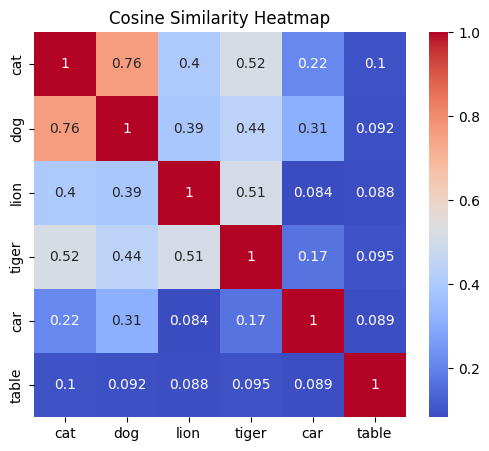

In [ ]:
#heatmap
df=pd.DataFrame(matrix,index=words,columns=words)

plt.figure(figsize=(6,5))

sns.heatmap(df,annot=True,cmap="coolwarm")

plt.title(f"{metric.capitalize()} Similarity Heatmap")

plt.show()

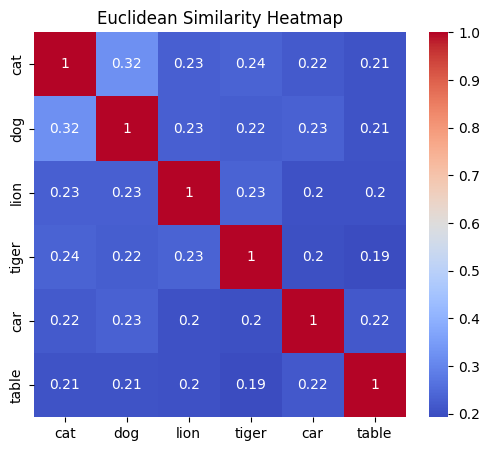

In [ ]:
words=["cat","dog","lion","tiger","car","table"]
metric = "euclidean"
#matrix
matrix = np.zeros((len(words), len(words)))

for i, w1 in enumerate(words):
    for j, w2 in enumerate(words):

        v1 = model[w1]
        v2 = model[w2]

        score = compute_metric(v1, v2, metric)

        if metric == "euclidean":
            score = 1/(1+score)

        matrix[i,j] = score
df=pd.DataFrame(matrix,index=words,columns=words)

plt.figure(figsize=(6,5))

sns.heatmap(df,annot=True,cmap="coolwarm")

plt.title(f"{metric.capitalize()} Similarity Heatmap")

plt.show()

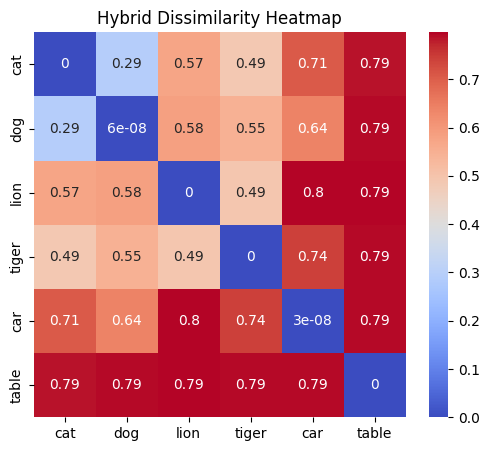

In [ ]:
words=["cat","dog","lion","tiger","car","table"]
metric = "hybrid"
#matrix
matrix = np.zeros((len(words), len(words)))

for i, w1 in enumerate(words):
    for j, w2 in enumerate(words):

        v1 = model[w1]
        v2 = model[w2]

        score = compute_metric(v1, v2, metric)

        if metric == "euclidean":
            score = 1/(1+score)

        matrix[i,j] = score
df=pd.DataFrame(matrix,index=words,columns=words)

plt.figure(figsize=(6,5))

sns.heatmap(df,annot=True,cmap="coolwarm")

plt.title(f"{metric.capitalize()} Dissimilarity Heatmap")

plt.show()

We compare three metrics for measuring word similarity: cosine similarity, Euclidean distance, and a hybrid dissimilarity metric. Cosine similarity measures the angle between embedding vectors and captures semantic similarity effectively. Euclidean distance measures the spatial distance between vectors in the embedding space.

The hybrid metric combines cosine similarity and normalized Euclidean distance to incorporate both directional similarity and spatial separation between embeddings. This allows the metric to capture semantic relationships while also considering the overall distance between vectors.

When ranking words relative to the target word "cat", cosine similarity correctly places semantically related words such as "dog", "tiger", and "lion" at the top. Euclidean distance produces a similar ranking but reflects the geometric distances between embeddings. The hybrid metric produces a balanced ranking that incorporates both perspectives. Heatmap visualizations further illustrate how different metrics capture relationships among words in the embedding space.
